In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

h = 0.01, total accumulated error = 0.45682138838236896
no previous iteration to compare
h = 0.06, total accumulated error = 0.39258577173051934
h=0.06, total error vs previous run = 0.31701134203006215
h = 0.11, total accumulated error = 0.43993981089209905
h=0.11, total error vs previous run = 0.2257273578738607
h = 0.16, total accumulated error = 0.3772009534961548
h=0.16, total error vs previous run = 0.08461464116639746
h = 0.21, total accumulated error = 0.3834920348904403
h=0.21, total error vs previous run = 0.1019822531009441
h = 0.26, total accumulated error = 0.3559420521483361
h=0.26, total error vs previous run = 0.060297314201018734
h = 0.31, total accumulated error = 0.42476481065971994
h=0.31, total error vs previous run = 0.12215987252957092
h = 0.36, total accumulated error = 0.41280168146839
h=0.36, total error vs previous run = 0.06444038684891411
h = 0.41, total accumulated error = 0.3520356716646532
h=0.41, total error vs previous run = 0.031458300159999994
h = 0.

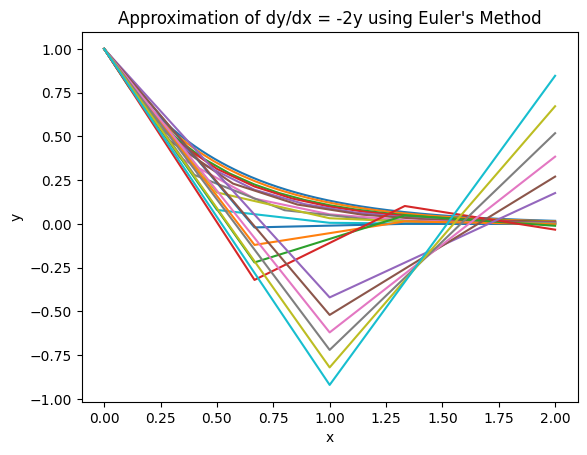

In [51]:
def true_solution(x):
    return np.exp(-2 * x)

# Define parameters
h_all = np.arange(0.01, 1.01, 0.05)
x_start, x_end = 0, 2

for i in range(len(h_all)):
  h = h_all[i]
  num_steps = int((x_end - x_start) / h)

  x_values = np.linspace(x_start, x_end, num_steps + 1)
  y_values = np.zeros(num_steps + 1)

  # Initial condition
  y_values[0] = 1  # y(0) = 1

  # Function representing dy/dx = -2y
  def f(x, y):
      return -2 * y

  # Implement Euler's method
  for j in range(num_steps):
      y_values[j + 1] = y_values[j] + h * f(x_values[j], y_values[j])

  true_vals = true_solution(x_values)
  total_error = np.sum(np.abs(y_values - true_vals))
  print(f"h = {h:.2f}, total accumulated error = {total_error}")

  # For the comparing run to run, the printing error by every point made console to much of a mess
  # decided to create splines for each run and compare the accumulated values from point to point
  # (spline for non matching points due to step sizes)

  if i == 0:
    prev_x = x_values
    prev_y = y_values
    print("no previous iteration to compare")
  else:
    spline_prev = CubicSpline(prev_x, prev_y)
    prev_interp_at_current = spline_prev(x_values)
    point_error = np.abs(y_values - prev_interp_at_current)
    error_for_prev = np.sum(point_error)
    print(f"h={h:.2f}, total error vs previous run = {error_for_prev}")
    prev_x = x_values
    prev_y = y_values

  plt.plot(x_values, y_values)

# Plot the results
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.show()